In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
tf.get_logger().setLevel('ERROR')

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/devarshkapure/dataset-final/All_Type_of_Report_(All_Grades)_30-03-2026_11-28-20_AM.csv


## Step 1 — Load & Clean Data (Jan 2024 – Mar 2026)

In [3]:
df = pd.read_csv('/kaggle/input/datasets/devarshkapure/dataset-final/All_Type_of_Report_(All_Grades)_30-03-2026_11-28-20_AM.csv')

# Auto-detect price columns regardless of date range in column name
min_col   = [c for c in df.columns if 'Min Price'   in c][0]
modal_col = [c for c in df.columns if 'Modal Price' in c][0]
max_col   = [c for c in df.columns if 'Max Price'   in c][0]

df = df.rename(columns={
    min_col:   'Min_Price',
    modal_col: 'Modal_Price',
    max_col:   'Max_Price',
})

df['Date']      = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df['Avg_Price'] = (df['Min_Price'] + df['Max_Price']) / 2

df = df[df['Commodity Group'] == 'Cereals'].copy()
df = df.dropna(subset=['Commodity', 'Modal_Price', 'Min_Price', 'Max_Price'])

print(f"Total records  : {len(df)}")
print(f"Date range     : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Unique days    : {df['Date'].nunique()}")
print(f"Years covered  : {(df['Date'].max() - df['Date'].min()).days / 365:.1f}")
print()
print("Records per year:")
print(df.groupby(df['Date'].dt.year).size().to_string())
print()
print(f"Commodities : {sorted(df['Commodity'].unique().tolist())}")


Total records  : 9992
Date range     : 2024-01-01 → 2026-03-28
Unique days    : 818
Years covered  : 2.2

Records per year:
Date
2024    4501
2025    4326
2026    1165

Commodities : ['Bajra(Pearl Millet/Cumbu)', 'Barley(Jau)', 'Beaten Rice', 'Foxtail Millet(Navane)', 'Hybrid Cumbu', 'Jaee', 'Jowar(Sorghum)', 'Kodo Millet(Varagu)', 'Kutki', 'Maize', 'Paddy(Basmati)', 'Paddy(Common)', 'Ragi(Finger Millet)', 'Rala', 'Rice', 'Sajje', 'Same/Savi', 'Sweet Corn ', 'T.V. Cumbu', 'Wheat']


## Step 2 — Select 12 Reliable Commodities (<50% missing data)

In [4]:
GOOD_COMMODITIES = [
    'Bajra(Pearl Millet/Cumbu)', 'Barley(Jau)',         'Foxtail Millet(Navane)',
    'Jowar(Sorghum)',            'Kodo Millet(Varagu)',  'Kutki',
    'Maize',                     'Paddy(Basmati)',       'Paddy(Common)',
    'Ragi(Finger Millet)',       'Rice',                 'Wheat'
]

df = df[df['Commodity'].isin(GOOD_COMMODITIES)]
print(f"Commodities kept : {df['Commodity'].nunique()}")
print(f"Records          : {len(df)}")
print()
print("Records per commodity per year:")
print(df.groupby([df['Date'].dt.year, 'Commodity']).size().unstack().fillna(0).astype(int).to_string())


Commodities kept : 12
Records          : 9127

Records per commodity per year:
Commodity  Bajra(Pearl Millet/Cumbu)  Barley(Jau)  Foxtail Millet(Navane)  Jowar(Sorghum)  Kodo Millet(Varagu)  Kutki  Maize  Paddy(Basmati)  Paddy(Common)  Ragi(Finger Millet)  Rice  Wheat
Date                                                                                                                                                                                         
2024                             366          366                     282             366                  335    139    366             366            366                  345   366    366
2025                             366          366                     264             366                  333    256    366             366            366                  319   366    366
2026                              87           87                      59              87                   83     77     87              85             87      

## Step 3 — Aggregate Per Day Per Commodity (mean across all markets)

In [5]:
df_agg = df.groupby(['Date', 'Commodity']).agg(
    Min_Price=('Min_Price',    'mean'),
    Max_Price=('Max_Price',    'mean'),
    Avg_Price=('Avg_Price',    'mean'),
    Modal_Price=('Modal_Price','mean'),
).reset_index()

print(f"Aggregated records : {len(df_agg)}")
print(df_agg.head(6))


Aggregated records : 9116
        Date                  Commodity  Min_Price  Max_Price  Avg_Price  \
0 2024-01-01  Bajra(Pearl Millet/Cumbu)    2215.69    2466.55   2341.120   
1 2024-01-01                Barley(Jau)    2015.15    2121.15   2068.150   
2 2024-01-01     Foxtail Millet(Navane)    6398.60    7265.60   6832.100   
3 2024-01-01             Jowar(Sorghum)    3877.94    4951.35   4414.645   
4 2024-01-01                      Maize    1945.29    2163.64   2054.465   
5 2024-01-01             Paddy(Basmati)    3565.20    3912.88   3739.040   

   Modal_Price  
0      2311.35  
1      2071.17  
2      6889.80  
3      4535.45  
4      2098.38  
5      3748.29  


## Step 4 — Build Wide Format (Min, Max, Avg, Modal per commodity)

In [6]:
price_types = {
    'Min_Price':   '_Min',
    'Max_Price':   '_Max',
    'Avg_Price':   '_Avg',
    'Modal_Price': '_Modal',
}

dfs = []
for col, suffix in price_types.items():
    piv = df_agg.pivot(index='Date', columns='Commodity', values=col)
    piv.columns = [f"{c}{suffix}" for c in piv.columns]
    dfs.append(piv)

wide_df = pd.concat(dfs, axis=1).sort_index()
print(f"Shape : {wide_df.shape}  ({wide_df.shape[0]} days × {wide_df.shape[1]} columns)")
print(wide_df.head(3))


Shape : (818, 48)  (818 days × 48 columns)
            Bajra(Pearl Millet/Cumbu)_Min  Barley(Jau)_Min  \
Date                                                         
2024-01-01                        2215.69          2015.15   
2024-01-02                        2191.79          2014.94   
2024-01-03                        2217.61          2024.13   

            Foxtail Millet(Navane)_Min  Jowar(Sorghum)_Min  \
Date                                                         
2024-01-01                     6398.60             3877.94   
2024-01-02                     5518.97             3061.95   
2024-01-03                     6009.00             2891.36   

            Kodo Millet(Varagu)_Min  Kutki_Min  Maize_Min  Paddy(Basmati)_Min  \
Date                                                                            
2024-01-01                      NaN        NaN    1945.29             3565.20   
2024-01-02                   2800.0        NaN    1955.69             3750.26   
2024-01-03 

## Step 5 — Fill Missing Dates & Values

In [7]:
full_range = pd.date_range(start=wide_df.index.min(),
                            end=wide_df.index.max(), freq='D')
wide_df = wide_df.reindex(full_range)
wide_df = wide_df.ffill()
wide_df = wide_df.bfill()

print(f"Total days    : {len(wide_df)}")
print(f"Date range    : {wide_df.index[0].date()} → {wide_df.index[-1].date()}")
print(f"NaN remaining : {wide_df.isnull().sum().sum()}")


Total days    : 818
Date range    : 2024-01-01 → 2026-03-28
NaN remaining : 0


## Step 5.5 — Add Seasonal Features
(Tells model WHEN in the year it is → fixes harvest season errors for Paddy/Jowar/Kutki)

In [8]:
# Encode month and week as sine/cosine so model understands cyclical seasons
# e.g. Jan and Dec are close to each other, not far apart

wide_df['month_sin'] = np.sin(2 * np.pi * wide_df.index.month / 12)
wide_df['month_cos'] = np.cos(2 * np.pi * wide_df.index.month / 12)

week_num = wide_df.index.isocalendar().week.values
wide_df['week_sin']  = np.sin(2 * np.pi * week_num / 52)
wide_df['week_cos']  = np.cos(2 * np.pi * week_num / 52)

print(f"Added 4 seasonal features.")
print(f"Total columns now : {wide_df.shape[1]}")
print(f"  48 price cols + 4 seasonal = {wide_df.shape[1]} (before lag)")


Added 4 seasonal features.
Total columns now : 52
  48 price cols + 4 seasonal = 52 (before lag)


## Step 6 — Add Lag Features (7-day and 14-day price memory)

In [9]:
modal_cols_raw = [c for c in wide_df.columns if c.endswith('_Modal')]

for col in modal_cols_raw:
    wide_df[f'{col}_lag7']  = wide_df[col].shift(7)
    wide_df[f'{col}_lag14'] = wide_df[col].shift(14)

wide_df = wide_df.dropna()

print(f"Shape after lag features : {wide_df.shape}")
print(f"  {wide_df.shape[0]} days × {wide_df.shape[1]} columns")
print(f"  (48 price + 4 seasonal + 24 lag = {wide_df.shape[1]} features)")
print(f"Date range after lag     : {wide_df.index[0].date()} → {wide_df.index[-1].date()}")


Shape after lag features : (804, 76)
  804 days × 76 columns
  (48 price + 4 seasonal + 24 lag = 76 features)
Date range after lag     : 2024-01-15 → 2026-03-28


## Step 7 — Define Features and Targets

In [10]:
feature_cols = list(wide_df.columns)
target_cols  = [c for c in wide_df.columns if c.endswith('_Modal') and 'lag' not in c]

print(f"Input features : {len(feature_cols)}")
print(f"  48 price cols + 4 seasonal + 24 lag = {len(feature_cols)} total")
print(f"Output targets : {len(target_cols)}  (next-day modal price per commodity)")
print()
print("Targets:")
for t in target_cols:
    print(f"  {t}")


Input features : 76
  48 price cols + 4 seasonal + 24 lag = 76 total
Output targets : 12  (next-day modal price per commodity)

Targets:
  Bajra(Pearl Millet/Cumbu)_Modal
  Barley(Jau)_Modal
  Foxtail Millet(Navane)_Modal
  Jowar(Sorghum)_Modal
  Kodo Millet(Varagu)_Modal
  Kutki_Modal
  Maize_Modal
  Paddy(Basmati)_Modal
  Paddy(Common)_Modal
  Ragi(Finger Millet)_Modal
  Rice_Modal
  Wheat_Modal


## Step 8 — Chronological Train / Validation / Test Split

In [11]:
wide_df = wide_df.sort_index()

n         = len(wide_df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = wide_df.iloc[:train_end]
val_df   = wide_df.iloc[train_end:val_end]
test_df  = wide_df.iloc[val_end:]

print(f"Total days : {n}")
print(f"Train      : {len(train_df)} days  {train_df.index[0].date()} → {train_df.index[-1].date()}")
print(f"Validation : {len(val_df)} days  {val_df.index[0].date()} → {val_df.index[-1].date()}")
print(f"Test       : {len(test_df)} days  {test_df.index[0].date()} → {test_df.index[-1].date()}")
print()
print("✅ Train covers Jan-Mar 2024 AND Jan-Mar 2025 harvest seasons")
print("   Model will now recognize seasonal price spikes in test period")


Total days : 804
Train      : 562 days  2024-01-15 → 2025-07-29
Validation : 121 days  2025-07-30 → 2025-11-27
Test       : 121 days  2025-11-28 → 2026-03-28

✅ Train covers Jan-Mar 2024 AND Jan-Mar 2025 harvest seasons
   Model will now recognize seasonal price spikes in test period


## Step 9 — Scale Features and Targets Separately

In [12]:
from sklearn.preprocessing import MinMaxScaler
import joblib

feature_scaler = MinMaxScaler(feature_range=(0, 1))
train_feat_scaled = feature_scaler.fit_transform(train_df[feature_cols])
val_feat_scaled   = feature_scaler.transform(val_df[feature_cols])
test_feat_scaled  = feature_scaler.transform(test_df[feature_cols])

target_scaler = MinMaxScaler(feature_range=(0, 1))
train_tgt_scaled = target_scaler.fit_transform(train_df[target_cols])
val_tgt_scaled   = target_scaler.transform(val_df[target_cols])
test_tgt_scaled  = target_scaler.transform(test_df[target_cols])

joblib.dump(feature_scaler, 'feature_scaler.pkl')
joblib.dump(target_scaler,  'target_scaler.pkl')

print(f"Feature scaler saved : {train_feat_scaled.shape}")
print(f"Target scaler saved  : {train_tgt_scaled.shape}")


Feature scaler saved : (562, 76)
Target scaler saved  : (562, 12)


## Step 9.5 — Save Column Names (columns.pkl)
(Required for loading and using the model in any future app or API)

In [16]:
import joblib

# Save all column metadata needed to reuse the model later
columns_info = {
    'feature_cols':     feature_cols,      # 76 input feature names in exact order
    'target_cols':      target_cols,       # 12 modal price target names in exact order
    'good_commodities': GOOD_COMMODITIES,  # 12 commodity names used
    'lookback':         LOOKBACK,          # sequence window size (14)
}

joblib.dump(columns_info, 'columns.pkl')

# Verify saved correctly
loaded = joblib.load('columns.pkl')
print("✅ columns.pkl saved successfully")
print()
print(f"feature_cols     : {len(loaded['feature_cols'])} columns")
print(f"target_cols      : {len(loaded['target_cols'])} columns")
print(f"good_commodities : {len(loaded['good_commodities'])} commodities")
print(f"lookback         : {loaded['lookback']} days")
print()
print("Feature columns (first 12):")
for c in loaded['feature_cols'][:12]:
    print(f"  {c}")
print(f"  ... ({len(loaded['feature_cols'])-12} more)")
print()
print("Target columns (modal prices to predict):")
for c in loaded['target_cols']:
    print(f"  {c}")
print()
print("Commodities included:")
for c in loaded['good_commodities']:
    print(f"  {c}")


✅ columns.pkl saved successfully

feature_cols     : 76 columns
target_cols      : 12 columns
good_commodities : 12 commodities
lookback         : 14 days

Feature columns (first 12):
  Bajra(Pearl Millet/Cumbu)_Min
  Barley(Jau)_Min
  Foxtail Millet(Navane)_Min
  Jowar(Sorghum)_Min
  Kodo Millet(Varagu)_Min
  Kutki_Min
  Maize_Min
  Paddy(Basmati)_Min
  Paddy(Common)_Min
  Ragi(Finger Millet)_Min
  Rice_Min
  Wheat_Min
  ... (64 more)

Target columns (modal prices to predict):
  Bajra(Pearl Millet/Cumbu)_Modal
  Barley(Jau)_Modal
  Foxtail Millet(Navane)_Modal
  Jowar(Sorghum)_Modal
  Kodo Millet(Varagu)_Modal
  Kutki_Modal
  Maize_Modal
  Paddy(Basmati)_Modal
  Paddy(Common)_Modal
  Ragi(Finger Millet)_Modal
  Rice_Modal
  Wheat_Modal

Commodities included:
  Bajra(Pearl Millet/Cumbu)
  Barley(Jau)
  Foxtail Millet(Navane)
  Jowar(Sorghum)
  Kodo Millet(Varagu)
  Kutki
  Maize
  Paddy(Basmati)
  Paddy(Common)
  Ragi(Finger Millet)
  Rice
  Wheat


## Step 10 — Create Sequences (Sliding Window, LOOKBACK=14 days)

In [15]:
LOOKBACK = 14

def create_sequences(features, targets, lookback):
    X, y = [], []
    for i in range(len(features) - lookback):
        X.append(features[i : i + lookback])
        y.append(targets[i + lookback])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_feat_scaled, train_tgt_scaled, LOOKBACK)
X_val,   y_val   = create_sequences(val_feat_scaled,   val_tgt_scaled,   LOOKBACK)
X_test,  y_test  = create_sequences(test_feat_scaled,  test_tgt_scaled,  LOOKBACK)

print(f"X_train : {X_train.shape}  → (samples, {LOOKBACK} days, {X_train.shape[2]} features)")
print(f"y_train : {y_train.shape}  → (samples, {y_train.shape[1]} modal prices)")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")


X_train : (548, 14, 76)  → (samples, 14 days, 76 features)
y_train : (548, 12)  → (samples, 12 modal prices)
X_val   : (107, 14, 76)
X_test  : (107, 14, 76)


## Step 11 — Build LSTM Model

**Architecture:**
- Bidirectional LSTM — reads time forward AND backward
- L2 regularization — prevents overfitting
- Dropout 0.4 — strong generalization
- Dense(64) bottleneck before output

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (LSTM, Dense, Dropout,
    BatchNormalization, Input, Bidirectional)
from tensorflow.keras.regularizers import l2

n_features = X_train.shape[2]
n_targets  = y_train.shape[1]

model = Sequential([
    Input(shape=(LOOKBACK, n_features)),

    Bidirectional(LSTM(64, return_sequences=True, kernel_regularizer=l2(1e-4))),
    Dropout(0.4),
    BatchNormalization(),

    LSTM(32, return_sequences=False, kernel_regularizer=l2(1e-4)),
    Dropout(0.4),
    BatchNormalization(),

    Dense(64, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.3),

    Dense(n_targets)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model.summary()
print(f"\nInput  : {LOOKBACK} days × {n_features} features")
print(f"Output : {n_targets} modal prices (one per commodity)")


I0000 00:00:1775013709.019547      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 14, 128)        │        72,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 14, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 96,332 (376.30 KB)

 Trainable params: 96,012 (375.05 KB)

 Non-trainable params: 320 (1.25 KB)


Input  : 14 days × 76 features
Output : 12 modal prices (one per commodity)


## Step 12 — Train the Model

In [18]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss', patience=25,
    restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=10, min_lr=1e-6, verbose=1
)
checkpoint = ModelCheckpoint(
    'best_lstm_model.keras',
    monitor='val_loss', save_best_only=True, verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)


Epoch 1/200


I0000 00:00:1775013722.935492     126 cuda_dnn.cc:529] Loaded cuDNN version 91002


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1090 - mae: 0.7961
Epoch 1: val_loss improved from inf to 0.17816, saving model to best_lstm_model.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - loss: 1.1015 - mae: 0.7932 - val_loss: 0.1782 - val_mae: 0.3310 - learning_rate: 0.0010
Epoch 2/200
13/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6115 - mae: 0.5866
Epoch 2: val_loss improved from 0.17816 to 0.14611, saving model to best_lstm_model.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.5909 - mae: 0.5762 - val_loss: 0.1461 - val_mae: 0.2855 - learning_rate: 0.0010
Epoch 3/200
13/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3888 - mae: 0.4651
Epoch 3: val_loss improved from 0.14611 to 0.13272, saving model to best_lstm_model.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3831 - mae: 0.4605 - val_loss: 0.1327 - val_mae: 0.2539 - learning_rate: 0.0010
Epoch 4/200
13/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3145 - mae: 0.4140 
Epoch 4: val_loss improved from 

## Step 13 — Plot Training History

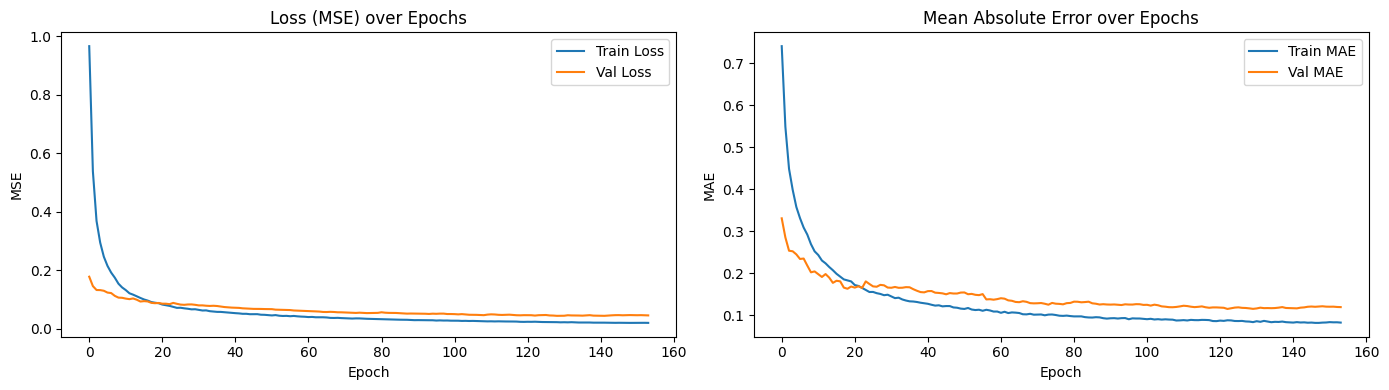

Saved → training_history.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss (MSE) over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()

axes[1].plot(history.history['mae'],     label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title('Mean Absolute Error over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()
print("Saved → training_history.png")


## Step 14 — Evaluate on Test Set

In [20]:
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss (MSE) : {test_loss:.6f}")
print(f"Test MAE        : {test_mae:.6f}")
print()

y_pred_scaled = model.predict(X_test, verbose=0)
per_col_mae   = np.abs(y_pred_scaled - y_test).mean(axis=0)
print("Per-commodity Scaled MAE (lower is better):")
for col, err in sorted(zip(target_cols, per_col_mae), key=lambda x: x[1]):
    status = '✅' if err < 0.10 else ('⚠️ ' if err < 0.25 else '❌')
    print(f"  {status} {col.replace('_Modal',''):35s}: {err:.4f}")


Test Loss (MSE) : 0.121752
Test MAE        : 0.240397

Per-commodity Scaled MAE (lower is better):
  ✅ Ragi(Finger Millet)                : 0.0853
  ✅ Wheat                              : 0.0857
  ✅ Kodo Millet(Varagu)                : 0.0898
  ⚠️  Kutki                              : 0.1079
  ⚠️  Barley(Jau)                        : 0.1198
  ⚠️  Bajra(Pearl Millet/Cumbu)          : 0.1426
  ⚠️  Foxtail Millet(Navane)             : 0.1899
  ⚠️  Jowar(Sorghum)                     : 0.2348
  ❌ Paddy(Basmati)                     : 0.3128
  ❌ Rice                               : 0.3466
  ❌ Paddy(Common)                      : 0.4009
  ❌ Maize                              : 0.7687


## Step 15 — Predict & Inverse Transform to Actual Rs./Quintal

In [21]:
y_pred_actual = target_scaler.inverse_transform(y_pred_scaled)
y_test_actual = target_scaler.inverse_transform(y_test)

test_dates = wide_df.index[-len(y_test_actual):]

pred_df = pd.DataFrame(y_pred_actual, columns=target_cols, index=test_dates)
true_df = pd.DataFrame(y_test_actual, columns=target_cols, index=test_dates)

pred_df.columns = [c.replace('_Modal','') for c in pred_df.columns]
true_df.columns = [c.replace('_Modal','') for c in true_df.columns]

print("Predicted Modal Prices (Rs./Quintal) — first 3 rows:")
print(pred_df.head(3).to_string())


Predicted Modal Prices (Rs./Quintal) — first 3 rows:
            Bajra(Pearl Millet/Cumbu)  Barley(Jau)  Foxtail Millet(Navane)  Jowar(Sorghum)  Kodo Millet(Varagu)        Kutki        Maize  Paddy(Basmati)  Paddy(Common)  Ragi(Finger Millet)         Rice        Wheat
2025-12-12                2398.616943  2171.503662             3089.658447     3037.411377          2259.299561  3111.276123  2117.283447     2913.781250    2281.663330          3370.110107  3353.498779  2536.833496
2025-12-13                2396.069336  2168.455322             3085.316650     3032.271484          2258.528564  3103.116455  2116.637695     2907.137451    2278.827637          3368.821045  3353.434570  2533.912598
2025-12-14                2399.687012  2173.962646             3089.982178     3035.902588          2258.152588  3113.894287  2118.392334     2914.100342    2282.546143          3368.842529  3354.629639  2540.313721


## Step 16 — Readable Comparison Table (Actual vs Predicted)

In [22]:
first_date = test_dates[0].date()

comparison = pd.DataFrame({
    'Commodity':                              pred_df.columns.tolist(),
    'Actual Modal Price (Rs./Quintal)':       true_df.iloc[0].values.round(2),
    'Predicted Modal Price (Rs./Quintal)':    pred_df.iloc[0].values.round(2),
})
comparison['Difference (Rs.)'] = (
    comparison['Predicted Modal Price (Rs./Quintal)'] -
    comparison['Actual Modal Price (Rs./Quintal)']
).round(2)
comparison['Error %'] = (
    comparison['Difference (Rs.)'].abs() /
    comparison['Actual Modal Price (Rs./Quintal)'] * 100
).round(2)

comparison = comparison.sort_values('Error %').reset_index(drop=True)

print(f"Date: {first_date}")
print(comparison.to_string(index=False))
print()
print(f"Mean Absolute Error : Rs. {comparison['Difference (Rs.)'].abs().mean():.2f}")
print(f"Mean Error %        : {comparison['Error %'].mean():.2f}%")

comparison.to_csv('modal_price_comparison.csv', index=False)
print("\nSaved → modal_price_comparison.csv")


Date: 2025-12-12
                Commodity  Actual Modal Price (Rs./Quintal)  Predicted Modal Price (Rs./Quintal)  Difference (Rs.)  Error %
                    Wheat                           2535.81                          2536.830078              1.02     0.04
           Jowar(Sorghum)                           3070.81                          3037.409912            -33.40     1.09
      Ragi(Finger Millet)                           3329.27                          3370.110107             40.84     1.23
Bajra(Pearl Millet/Cumbu)                           2440.85                          2398.620117            -42.23     1.73
              Barley(Jau)                           2268.73                          2171.500000            -97.23     4.29
                    Kutki                           3300.00                          3111.280029           -188.72     5.72
           Paddy(Basmati)                           3226.13                          2913.780029           -312.35 

## Step 17 — Future Price Forecasting (Next 7 Days)

In [23]:
def forecast_future(model, last_window_features, feature_scaler,
                       target_scaler, feature_cols, target_cols,
                       wide_df, n_days=7):
    current_window = last_window_features.copy()
    future_preds   = []
    feature_idx    = {col: i for i, col in enumerate(feature_cols)}
    target_idx     = {col: i for i, col in enumerate(target_cols)}

    for day in range(n_days):
        x_input     = current_window.reshape(1, LOOKBACK, len(feature_cols))
        pred_scaled = model.predict(x_input, verbose=0)[0]
        future_preds.append(pred_scaled)

        new_row = current_window[-1].copy()
        for t_col, t_idx in target_idx.items():
            f_idx = feature_idx.get(t_col)
            if f_idx is not None:
                new_row[f_idx] = pred_scaled[t_idx]

        # Update seasonal features for next day
        next_date = wide_df.index[-1] + pd.Timedelta(days=day+1)
        for feat, val in [
            ('month_sin', np.sin(2*np.pi*next_date.month/12)),
            ('month_cos', np.cos(2*np.pi*next_date.month/12)),
            ('week_sin',  np.sin(2*np.pi*next_date.isocalendar()[1]/52)),
            ('week_cos',  np.cos(2*np.pi*next_date.isocalendar()[1]/52)),
        ]:
            if feat in feature_idx:
                new_row[feature_idx[feat]] = val

        current_window = np.vstack([current_window[1:], new_row])

    future_preds_actual = target_scaler.inverse_transform(np.array(future_preds))
    last_date    = wide_df.index[-1]
    future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=n_days)
    forecast_df  = pd.DataFrame(
        future_preds_actual,
        columns=[c.replace('_Modal','') for c in target_cols],
        index=future_dates
    )
    return forecast_df

last_window = test_feat_scaled[-LOOKBACK:]
N_FORECAST  = 7
forecast_df = forecast_future(model, last_window, feature_scaler,
                               target_scaler, feature_cols, target_cols,
                               wide_df, n_days=N_FORECAST)

print(f"Forecasted Modal Prices — next {N_FORECAST} days (Rs./Quintal):")
print(forecast_df.round(2).to_string())
forecast_df.to_csv('future_forecast.csv')
print("\nSaved → future_forecast.csv")


Forecasted Modal Prices — next 7 days (Rs./Quintal):
            Bajra(Pearl Millet/Cumbu)  Barley(Jau)  Foxtail Millet(Navane)  Jowar(Sorghum)  Kodo Millet(Varagu)        Kutki        Maize  Paddy(Basmati)  Paddy(Common)  Ragi(Finger Millet)         Rice        Wheat
2026-03-29                2361.969971  2096.000000             3403.310059     3081.179932          2357.719971  3260.739990  2091.989990     2986.780029    2284.590088          3383.500000  3348.320068  2466.229980
2026-03-30                2361.449951  2100.270020             3363.219971     3077.590088          2347.469971  3258.979980  2090.989990     2974.639893    2279.320068          3392.040039  3348.560059  2467.610107
2026-03-31                2361.280029  2102.620117             3338.129883     3073.570068          2340.919922  3254.659912  2090.899902     2964.909912    2276.540039          3394.389893  3348.540039  2469.060059
2026-04-01                2361.290039  2104.370117             3319.360107     3069

## Step 18 — Plot Actual vs Predicted + Future Forecast

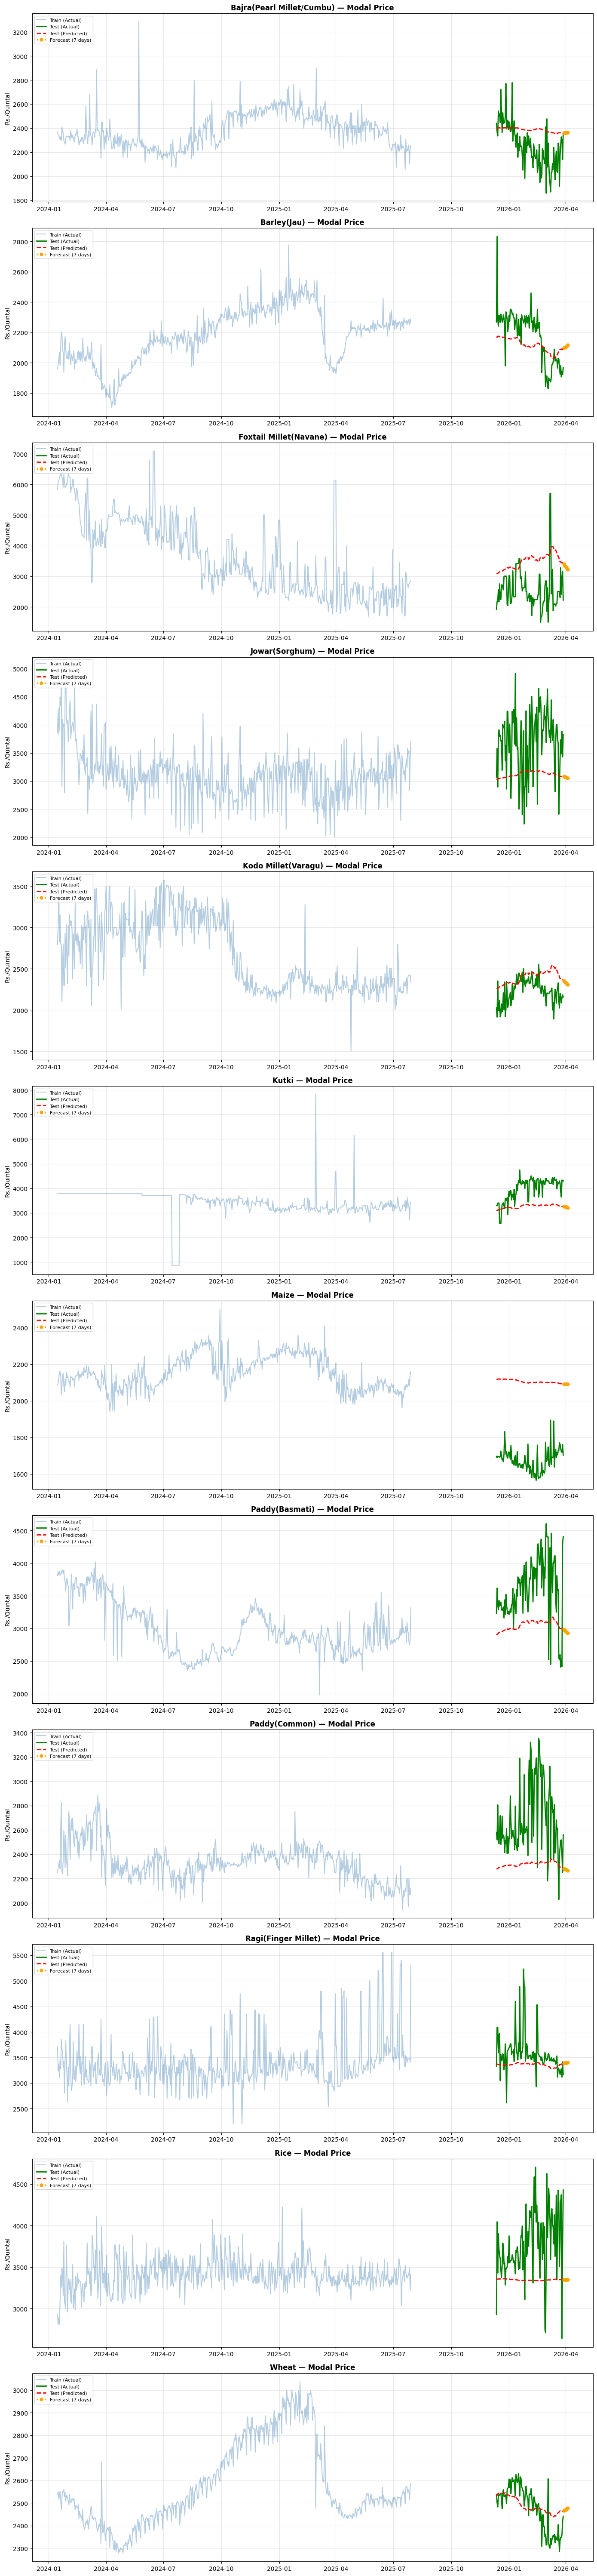

Saved → all_commodities_prediction.png


In [24]:
modal_train = wide_df[[c for c in wide_df.columns
                         if c.endswith('_Modal') and 'lag' not in c]].copy()
modal_train.columns = [c.replace('_Modal','') for c in modal_train.columns]
train_plot_df = modal_train.iloc[:train_end]

n_comms = len(pred_df.columns)
fig, axes = plt.subplots(n_comms, 1, figsize=(14, 5 * n_comms))

for ax, commodity in zip(axes, pred_df.columns):
    ax.plot(train_plot_df.index, train_plot_df[commodity],
            label='Train (Actual)', color='steelblue', alpha=0.4)
    ax.plot(true_df.index,  true_df[commodity],
            label='Test (Actual)',    color='green',  linewidth=2)
    ax.plot(pred_df.index,  pred_df[commodity],
            label='Test (Predicted)', color='red', linestyle='--', linewidth=2)
    if commodity in forecast_df.columns:
        ax.plot(forecast_df.index, forecast_df[commodity],
                label=f'Forecast ({N_FORECAST} days)', color='orange',
                linestyle=':', linewidth=2.5, marker='o', markersize=5)
    ax.set_title(f'{commodity} — Modal Price', fontsize=12, fontweight='bold')
    ax.set_ylabel('Rs./Quintal')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('all_commodities_prediction.png', dpi=120)
plt.show()
print("Saved → all_commodities_prediction.png")


## Step 19 — Save All Results

In [25]:
pred_df.to_csv('predictions_modal.csv')
true_df.to_csv('actuals_modal.csv')
comparison.to_csv('modal_price_comparison.csv', index=False)
forecast_df.to_csv('future_forecast.csv')
model.save('lstm_modal_price_model.keras')

# Re-save columns.pkl to ensure it's included in Kaggle outputs
joblib.dump(columns_info, 'columns.pkl')

print("All files saved:")
print("  → predictions_modal.csv           (test period predicted prices)")
print("  → actuals_modal.csv               (test period actual prices)")
print("  → modal_price_comparison.csv      (actual vs predicted table with error %)")
print("  → future_forecast.csv             (next 7 days forecast)")
print("  → all_commodities_prediction.png  (plots for all 12 commodities)")
print("  → training_history.png            (loss & MAE curves)")
print("  → lstm_modal_price_model.keras    (full trained model)")
print("  → best_lstm_model.keras           (best checkpoint)")
print("  → feature_scaler.pkl              (input feature scaler)")
print("  → target_scaler.pkl               (modal price target scaler)")
print("  → columns.pkl                     (feature & target column names + metadata)")


All files saved:
  → predictions_modal.csv           (test period predicted prices)
  → actuals_modal.csv               (test period actual prices)
  → modal_price_comparison.csv      (actual vs predicted table with error %)
  → future_forecast.csv             (next 7 days forecast)
  → all_commodities_prediction.png  (plots for all 12 commodities)
  → training_history.png            (loss & MAE curves)
  → lstm_modal_price_model.keras    (full trained model)
  → best_lstm_model.keras           (best checkpoint)
  → feature_scaler.pkl              (input feature scaler)
  → target_scaler.pkl               (modal price target scaler)
  → columns.pkl                     (feature & target column names + metadata)
